#### Short-Channel Effects & DIBL

Drain Current ($I_D$) versus Gate Voltage ($V_{GS}$) across varying gate lengths ($L_g$) to demonstrate how device geometry governs Drain-Induced Barrier Lowering (DIBL).

#### Why Gate Length ($L_g$) Matters
Electrostatic control depends on the aspect ratio between gate length ($L_g$) and effective vertical distance ($d$) from the gate to the channel:

   * High Aspect Ratio ($L_g \gg d$): In long channels, the gate field controls the channel potential, preventing the drain's electric field from reaching the source, causing minimal shift in threshold voltage.
   * Low Aspect Ratio ($L_g \approx d$): In short channels, the gate field loses control of the channel center. The depletion region around the drain expands laterally under the gate, reaching the source potential barrier and lowering it prematurely.



 RUNNING: L_g = 30 nm | V_DS = 2.0 V | V_GS = 2.00 V
Iter   0 | ΔV: 5947.72mV | Max T: 300.0K | I_D: 47.83 mA/mm | Max n_s: 1.21e+12 cm^-2
Iter  20 | ΔV: 864.24mV | Max T: 303.3K | I_D: 2638.27 mA/mm | Max n_s: 3.87e+13 cm^-2
Iter  40 | ΔV: 287.03mV | Max T: 307.3K | I_D: 2269.32 mA/mm | Max n_s: 6.63e+13 cm^-2
Iter  60 | ΔV: 98.50mV | Max T: 311.3K | I_D: 2107.08 mA/mm | Max n_s: 8.18e+13 cm^-2
Iter  80 | ΔV: 56.17mV | Max T: 315.3K | I_D: 2380.10 mA/mm | Max n_s: 8.89e+13 cm^-2
Iter 100 | ΔV: 55.33mV | Max T: 319.3K | I_D: 2734.18 mA/mm | Max n_s: 9.06e+13 cm^-2
Iter 120 | ΔV: 53.71mV | Max T: 323.3K | I_D: 2741.59 mA/mm | Max n_s: 8.89e+13 cm^-2
Iter 140 | ΔV: 49.07mV | Max T: 327.3K | I_D: 2384.57 mA/mm | Max n_s: 8.54e+13 cm^-2
Iter 160 | ΔV: 36.92mV | Max T: 331.3K | I_D: 1913.82 mA/mm | Max n_s: 8.11e+13 cm^-2
Iter 180 | ΔV: 21.12mV | Max T: 335.3K | I_D: 1481.07 mA/mm | Max n_s: 7.66e+13 cm^-2
Iter 200 | ΔV: 36.45mV | Max T: 339.2K | I_D: 1170.37 mA/mm | Max n_s: 7.23e+13 cm^-

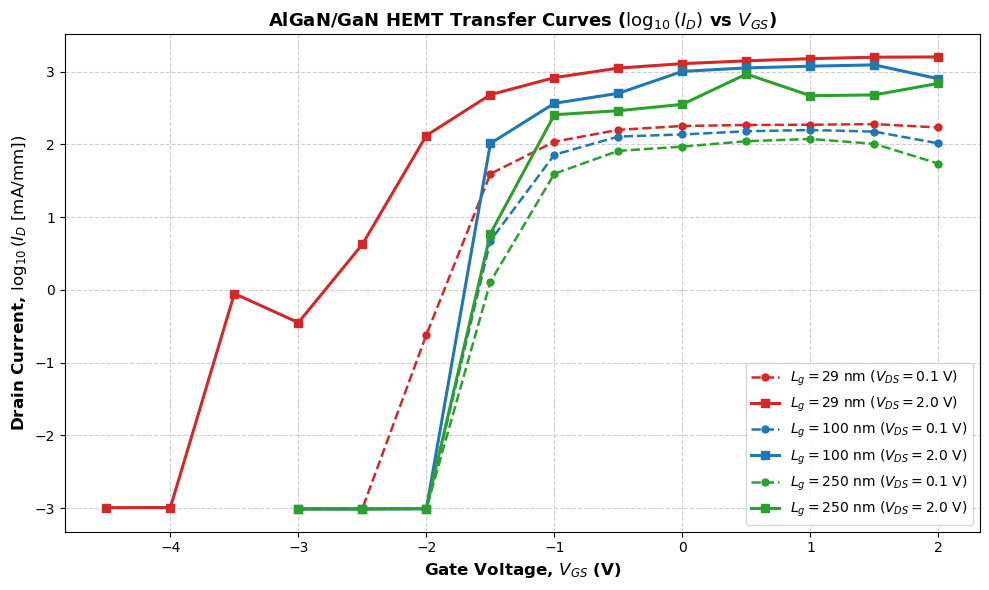

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as spla
import scipy.linalg as la
import scipy.constants as const


# 1. PHYSICAL CONSTANTS & SOLVER FUNCTION
q = const.e
hbar = const.hbar
eps0 = const.epsilon_0
kB = const.k
T_amb = 300.0  # Ambient temperature (K)
m0 = const.m_e

def run_hemt_simulation(L_g_val, Vds_val, Vg_sweep):
    """
    Runs the 2D Electro-Thermal Poisson-Schrödinger-Transport solver for a given
    gate length (L_g_val) and drain bias (Vds_val) across a gate voltage sweep.
    """
    # Material and Transport Parameters
    x_al = 0.22
    V_schottky = 1.2
    V_surface_pin = -1.2
    mu_0 = 0.12
    v_sat_300K = 1.1e5
    beta_CT = 2.0

    kappa_GaN = 130.0
    kappa_AlGaN = 20.0
    gamma_mu = 2.0
    gamma_vsat = 1.5

    E_dA = 2.5 * q
    g_A = 4.0

    m_GaN = 0.20 * m0
    m_AlGaN = (0.32 * x_al + 0.20 * (1.0 - x_al)) * m0
    eps_GaN = 8.9 * eps0
    eps_AlGaN = (8.5 * x_al + 8.9 * (1.0 - x_al)) * eps0
    dE_c = 0.7 * (3.07 * x_al + 0.7 * x_al * (1.0 - x_al)) * q

    # Spontaneous & Piezoelectric Polarization
    P_SP_GaN = -0.034
    P_SP_AlGaN = -0.090 * x_al - 0.034 * (1.0 - x_al) + 0.021 * x_al * (1.0 - x_al)
    a_GaN, a_AlN = 0.3189e-9, 0.3112e-9
    a_AlGaN = a_AlN * x_al + a_GaN * (1.0 - x_al)
    strain_inplane = (a_GaN - a_AlGaN) / a_AlGaN
    e31 = -0.11 * x_al - 0.49 * (1.0 - x_al)
    e33 = 0.73 * x_al + 0.97 * (1.0 - x_al)
    C13 = (103 * x_al + 106 * (1.0 - x_al)) * 1e9
    C33 = (405 * x_al + 398 * (1.0 - x_al)) * 1e9
    P_PE_AlGaN = 2 * strain_inplane * (e31 - e33 * (C13 / C33))
    sigma_pol = (P_SP_GaN - (P_SP_AlGaN + P_PE_AlGaN)) / q

    # Device Geometry
    L_s, L_sg, L_gd, L_d = 15e-9, 20e-9, 20e-9, 15e-9
    Lx = L_s + L_sg + L_g_val + L_gd + L_d
    t_barrier, t_buffer = 12.0e-9, 288.0e-9
    Lz = t_barrier + t_buffer

    # Mesh Generation
    z_top = np.linspace(0, 9e-9, 15, endpoint=False)
    z_2deg = np.linspace(9e-9, 18e-9, 65, endpoint=False)
    z_buf = np.geomspace(18e-9, Lz, 40)
    z = np.unique(np.sort(np.concatenate([z_top, z_2deg, z_buf])))
    Nz = len(z)

    x_gate1 = L_s + L_sg
    x_gate2 = x_gate1 + L_g_val
    x_s = np.linspace(0, L_s, 10, endpoint=False)
    x_sg = np.linspace(L_s, x_gate1, 15, endpoint=False)
    n_g_points = max(25, int(25 * (L_g_val / 30e-9)))
    x_g = np.linspace(x_gate1, x_gate2, n_g_points, endpoint=False)
    x_gd = np.linspace(x_gate2, Lx - L_d, 15, endpoint=False)
    x_d = np.linspace(Lx - L_d, Lx, 15)
    x = np.unique(np.sort(np.concatenate([x_s, x_sg, x_g, x_gd, x_d])))
    Nx = len(x)

    X, Z = np.meshgrid(x, z)
    idx_int = np.argmin(np.abs(z - t_barrier))

    dx_R = np.diff(x); dx_L = np.roll(dx_R, 1)
    dx_avg = 0.5 * (np.append(dx_R, dx_R[-1]) + np.insert(dx_L, 0, dx_L[0]))
    dz_R = np.diff(z); dz_L = np.roll(dz_R, 1)
    dz_avg = 0.5 * (np.append(dz_R, dz_R[-1]) + np.insert(dz_L, 0, dz_L[0]))

    m_eff = np.where(Z <= t_barrier, m_AlGaN, m_GaN)
    eps_r = np.where(Z <= t_barrier, eps_AlGaN, eps_GaN)
    kappa_grid = np.where(Z <= t_barrier, kappa_AlGaN, kappa_GaN)
    V_band = np.where(Z <= t_barrier, dE_c, 0.0)

    source_mask = (X <= L_s) & (Z == 0)
    gate_mask = (X >= x_gate1) & (X <= x_gate2) & (Z == 0)
    drain_mask = (X >= Lx - L_d) & (Z == 0)

    # Doping
    rho_fixed = np.zeros((Nz, Nx))
    rho_fixed[idx_int+1:, :] += q * 1e22
    rho_fixed[idx_int, :] += (q * sigma_pol) / dz_avg[idx_int]

    N_D_contacts = 2e25
    contact_depth = t_barrier + 2e-9
    rho_fixed[(X <= L_s) & (Z <= contact_depth)] += q * N_D_contacts
    rho_fixed[(X >= Lx - L_d) & (Z <= contact_depth)] += q * N_D_contacts

    t_buffer_doped_start = t_barrier + 20e-9
    idx_buffer_doped = np.max(np.where(z <= t_buffer_doped_start)[0])
    N_acceptor = 5e22

    buf_trap_mask = np.zeros((Nz, Nx), dtype=bool)
    buf_trap_mask[idx_buffer_doped:, :] = True

    N_C_GaN = 2.0 * ((m_GaN * kB * T_amb) / (2.0 * np.pi * hbar**2))**1.5
    n_ratio = N_D_contacts / N_C_GaN
    V_bi = (kB * T_amb / q) * (np.log(n_ratio) + n_ratio / np.sqrt(8))

    # 2D Matrices Setup
    N_tot = Nx * Nz
    A_poisson_base = sparse.lil_matrix((N_tot, N_tot))
    A_therm_base = sparse.lil_matrix((N_tot, N_tot))

    def get_k(i, j): return j * Nx + i

    for j in range(Nz):
        for i in range(Nx):
            k = get_k(i, j)
            # Poisson BCs
            if gate_mask[j, i] or source_mask[j, i] or drain_mask[j, i] or j == 0:
                A_poisson_base[k, k] = 1.0
            elif j == Nz - 1:
                A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i, j-1)] = -1.0
            elif i == 0:
                A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i+1, j)] = -1.0
            elif i == Nx - 1:
                A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i-1, j)] = -1.0
            else:
                dx_r_i, dx_l_i, dx_a_i = dx_R[i], dx_R[i-1], dx_avg[i]
                dz_r_j, dz_l_j, dz_a_j = dz_R[j], dz_R[j-1], dz_avg[j]
                exP = 0.5 * (eps_r[j, i] + eps_r[j, i+1]); exM = 0.5 * (eps_r[j, i] + eps_r[j, i-1])
                ezP = 0.5 * (eps_r[j, i] + eps_r[j+1, i]); ezM = 0.5 * (eps_r[j, i] + eps_r[j-1, i])
                c_iP, c_iM = exP / (dx_a_i * dx_r_i), exM / (dx_a_i * dx_l_i)
                c_jP, c_jM = ezP / (dz_a_j * dz_r_j), ezM / (dz_a_j * dz_l_j)
                A_poisson_base[k, get_k(i+1, j)] = c_iP; A_poisson_base[k, get_k(i-1, j)] = c_iM
                A_poisson_base[k, get_k(i, j+1)] = c_jP; A_poisson_base[k, get_k(i, j-1)] = c_jM
                A_poisson_base[k, k] = -(c_iP + c_iM + c_jP + c_jM)

            # Thermal BCs
            if j == Nz - 1:
                A_therm_base[k, k] = 1.0
            elif i == 0:
                A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i+1, j)] = -1.0
            elif i == Nx - 1:
                A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i-1, j)] = -1.0
            elif j == 0:
                A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i, j+1)] = -1.0
            else:
                dx_r_i, dx_l_i, dx_a_i = dx_R[i], dx_R[i-1], dx_avg[i]
                dz_r_j, dz_l_j, dz_a_j = dz_R[j], dz_R[j-1], dz_avg[j]
                kxP = 0.5 * (kappa_grid[j, i] + kappa_grid[j, i+1]); kxM = 0.5 * (kappa_grid[j, i] + kappa_grid[j, i-1])
                kzP = 0.5 * (kappa_grid[j, i] + kappa_grid[j+1, i]); kzM = 0.5 * (kappa_grid[j, i] + kappa_grid[j-1, i])
                tc_iP, tc_iM = kxP / (dx_a_i * dx_r_i), kxM / (dx_a_i * dx_l_i)
                tc_jP, tc_jM = kzP / (dz_a_j * dz_r_j), kzM / (dz_a_j * dz_l_j)
                A_therm_base[k, get_k(i+1, j)] = tc_iP; A_therm_base[k, get_k(i-1, j)] = tc_iM
                A_therm_base[k, get_k(i, j+1)] = tc_jP; A_therm_base[k, get_k(i, j-1)] = tc_jM
                A_therm_base[k, k] = -(tc_iP + tc_iM + tc_jP + tc_jM)

    A_csr = A_poisson_base.tocsr()
    A_therm_csr = A_therm_base.tocsr()

    max_iter_limit = 3000
    min_iters = 250
    n_subbands = 3

    window_size = 5
    convergence_tol = 1e-4
    max_diverge_steps = 3
    trend_window_size = max_diverge_steps * 2

    alpha_p, alpha_n, alpha_EF, alpha_T = 0.05, 0.025, 0.025, 0.02

    extracted_Vg = []
    extracted_Id = []

    dirichlet_mask = gate_mask | source_mask | drain_mask
    surface_pin_mask = (Z == 0) & ~dirichlet_mask
    outer_bc_mask = ((Z == Lz) | (X == 0) | (X == Lx)) & (Z > 0)
    interior_mask = ~(dirichlet_mask | surface_pin_mask | outer_bc_mask)

    N_DOS_3D_equiv = np.broadcast_to((m_GaN * kB * T_amb) / (np.pi * hbar**2 * dz_avg[:, np.newaxis]), (Nz, Nx))
    idx_qbox = np.argmin(np.abs(z - (t_barrier + 95.0e-9)))
    N_int = idx_qbox - 2

    for Vg_current in Vg_sweep:
        print("\n" + "="*65)
        print(f" RUNNING: L_g = {L_g_val*1e9:.0f} nm | V_DS = {Vds_val:.1f} V | V_GS = {Vg_current:.2f} V")
        print("="*65)

        Id_history = []
        moving_avg_prev = None
        diverge_count = 0
        best_stable_Id = 0.0
        recent_trends = []

        phi = np.zeros((Nz, Nx))
        n_2d = np.zeros((Nz, Nx))
        T_2d = np.full((Nz, Nx), T_amb)
        T_channel = np.full(Nx, T_amb)
        V_tot = np.copy(V_band)

        V_ef_lat = np.linspace(0, Vds_val, Nx)
        E_F_lat = -q * V_ef_lat

        b_base_2d = np.zeros((Nz, Nx))
        b_base_2d[gate_mask] = Vg_current - (V_schottky - dE_c / q)
        b_base_2d[source_mask] = V_bi
        b_base_2d[drain_mask] = Vds_val + V_bi
        b_base_2d[surface_pin_mask] = V_surface_pin

        Ex_abs = np.zeros(Nx)
        mu_field = np.zeros(Nx)
        I_d_channel = np.zeros(Nx)
        I_d_avg = 0.0

        for iteration in range(max_iter_limit):
            # A. Poisson Block
            b_2d = np.copy(b_base_2d)
            E_C = V_band - q * phi; E_A = E_C - E_dA
            E_Fn = E_F_lat[np.newaxis, :]
            
            exp_term_A = g_A * np.exp(np.clip((E_A - E_Fn) / (kB * T_amb), -700.0, 700.0))
            f_A = 1.0 / (1.0 + exp_term_A)
            
            rho_trap = np.zeros((Nz, Nx))
            rho_trap[buf_trap_mask] = -q * N_acceptor * f_A[buf_trap_mask]
            rho_total = rho_fixed + rho_trap
            b_2d[interior_mask] = -(rho_total[interior_mask] - q * n_2d[interior_mask])

            term_n = np.exp(-np.minimum(n_2d[interior_mask] / N_DOS_3D_equiv[interior_mask], 700.0))
            D_electrons = (q**2 * N_DOS_3D_equiv[interior_mask] / (kB * T_amb)) * (1.0 - term_n)
            
            exp_A_sub = exp_term_A[buf_trap_mask]
            df_dE = np.where(exp_A_sub > 1e15, 0.0, exp_A_sub / (1.0 + exp_A_sub)**2)
            D_traps = np.zeros((Nz, Nx))
            D_traps[buf_trap_mask] = (q**2 * N_acceptor / (kB * T_amb)) * df_dE

            D_gummel_2d = np.zeros((Nz, Nx))
            D_gummel_2d[interior_mask] = D_electrons + D_traps[interior_mask]
            D_gummel_flat = D_gummel_2d.flatten()

            A_gummel_dynamic = A_csr - sparse.diags(D_gummel_flat, format='csr')
            b_gummel_dynamic = b_2d.flatten() - D_gummel_flat * phi.flatten()
            
            phi_new = spla.spsolve(A_gummel_dynamic, b_gummel_dynamic).reshape((Nz, Nx))
            err_phi = np.max(np.abs(phi_new - phi))
            
            phi = alpha_p * phi_new + (1 - alpha_p) * phi
            V_tot = np.clip(V_band - q * phi, -15 * q, 5 * q)

            # B. Schrödinger Block
            n_new = np.zeros((Nz, Nx))
            V_xc_raw = -(q**2 / (4.0 * np.pi * eps_r)) * (3.0 * np.maximum(n_2d, 1e12) / np.pi)**(1.0 / 3.0)
            V_xc = np.clip(V_xc_raw, -0.05 * q, 0.0)
            V_quantum_2d = V_tot + V_xc

            for i in range(Nx):
                V_quantum = V_quantum_2d[:idx_qbox, i]; m_col = m_eff[:idx_qbox, i]
                d_int = np.zeros(N_int); e_int = np.zeros(N_int - 1)
                for k in range(N_int):
                    j_idx = k + 1
                    dz_r, dz_l, dz_a = dz_R[j_idx], dz_R[j_idx-1], dz_avg[j_idx]
                    inv_mp = 0.5 * (1.0 / m_col[j_idx] + 1.0 / m_col[j_idx+1])
                    inv_mm = 0.5 * (1.0 / m_col[j_idx] + 1.0 / m_col[j_idx-1])
                    d_int[k] = V_quantum[j_idx] + (hbar**2 / (2.0 * dz_a)) * (inv_mp / dz_r + inv_mm / dz_l)
                    if k < N_int - 1:
                        e_int[k] = -(hbar**2 / 2.0) * (inv_mp / dz_r) / np.sqrt(dz_a * dz_avg[j_idx+1])

                evals, evecs_int = la.eigh_tridiagonal(d_int, e_int, select='i', select_range=(0, n_subbands-1))
                evecs_full = np.zeros((idx_qbox, n_subbands))
                evecs_full[1:-1, :] = evecs_int

                for m in range(n_subbands):
                    m_eff_subband = m_GaN * (1.0 + (0.6 / q) * np.maximum(evals[m] - V_quantum[idx_int], 0.0))
                    n_s = ((m_eff_subband * kB * T_amb) / (np.pi * hbar**2)) * np.logaddexp(0, (E_F_lat[i] - evals[m]) / (kB * T_amb))
                    u_sq = evecs_full[:, m]**2
                    psi_sq = (u_sq / dz_avg[:idx_qbox]) / np.sum(u_sq)
                    psi_sq_full = np.zeros(Nz); psi_sq_full[:idx_qbox] = psi_sq
                    n_new[:, i] += n_s * psi_sq_full

            n_2d = alpha_n * n_new + (1 - alpha_n) * n_2d

            # C. Electro-Thermal Transport Block
            n_s_eff = np.maximum(np.sum(n_2d * dz_avg[:, np.newaxis], axis=0), 1e10)
            mu_T_scale = (T_amb / T_channel)**gamma_mu
            v_sat_T_scale = (T_amb / T_channel)**gamma_vsat

            mu_pop, mu_dis, mu_irs, n_ref = 0.15, 0.20, 0.10, 1.0e17
            inv_mu_dis = 1.0 / (mu_dis * (n_s_eff / n_ref)**0.5)
            inv_mu_pop = 1.0 / mu_pop
            inv_mu_irs = 1.0 / (mu_irs * (n_ref / n_s_eff)**2.5)

            mu_0_lat = (1.0 / (inv_mu_dis + inv_mu_pop + inv_mu_irs)) * mu_T_scale
            v_sat_lat = v_sat_300K * v_sat_T_scale

            Ex = np.zeros(Nx)
            Ex[1:-1] = -(phi[idx_int, 2:] - phi[idx_int, :-2]) / (x[2:] - x[:-2])
            Ex[0] = -(phi[idx_int, 1] - phi[idx_int, 0]) / dx_R[0]
            Ex[-1] = -(phi[idx_int, -1] - phi[idx_int, -2]) / dx_R[-1]
            Ex_abs = np.maximum(np.abs(Ex), 1e2)

            den_mobility = (1.0 + (mu_0_lat * Ex_abs / v_sat_lat)**beta_CT)**(1.0 / beta_CT)
            mu_field = mu_0_lat / den_mobility
            G_eff = n_s_eff * mu_field
            G_mid = 2.0 * (G_eff[:-1] * G_eff[1:]) / (G_eff[:-1] + G_eff[1:] + 1e-30)

            R_c = 1.2e-3
            I_est = np.mean(I_d_channel[1:-1]) if iteration > 0 else 1000.0
            V_s_eff = (I_est * 1e-3) * R_c
            V_d_eff = Vds_val - (I_est * 1e-3) * R_c

            A_1D = sparse.lil_matrix((Nx, Nx)); b_1D = np.zeros(Nx)
            for i in range(Nx):
                if i == 0:
                    A_1D[i, i] = 1.0; b_1D[i] = V_s_eff
                elif i == Nx - 1:
                    A_1D[i, i] = 1.0; b_1D[i] = V_d_eff
                else:
                    lc, rc = G_mid[i - 1] / dx_R[i - 1], G_mid[i] / dx_R[i]
                    A_1D[i, i - 1] = lc; A_1D[i, i + 1] = rc; A_1D[i, i] = -(lc + rc)

            V_ef_new = spla.spsolve(A_1D.tocsr(), b_1D)
            V_ef_lat = alpha_EF * V_ef_new + (1 - alpha_EF) * V_ef_lat
            E_F_lat = -q * V_ef_lat

            dVef_dx = np.zeros(Nx)
            dVef_dx[1:-1] = (V_ef_lat[2:] - V_ef_lat[:-2]) / (x[2:] - x[:-2])
            dVef_dx[0], dVef_dx[-1] = (V_ef_lat[1]-V_ef_lat[0])/dx_R[0], (V_ef_lat[-1]-V_ef_lat[-2])/dx_R[-1]

            I_d_channel = q * G_eff * dVef_dx
            I_d_avg = np.mean(I_d_channel[1:-1])

            P_diss_vol = (I_d_channel * Ex_abs) / dz_avg[idx_int]
            b_therm = np.zeros(N_tot)
            for i in range(1, Nx-1):
                b_therm[get_k(i, idx_int)] = -P_diss_vol[i]
            for i in range(Nx):
                b_therm[get_k(i, Nz-1)] = T_amb

            T_flat = spla.spsolve(A_therm_csr, b_therm)
            T_2d_new = T_flat.reshape((Nz, Nx))
            dT = np.clip(T_2d_new - T_2d, -10.0, 10.0)
            T_2d = T_2d + alpha_T * dT
            T_channel = T_2d[idx_int, :]

            # Show status every 20th iteration
            if iteration % 20 == 0:
                peak_ns_cm2 = np.max(n_s_eff) / 1e4
                print(f"Iter {iteration:3d} | ΔV: {err_phi*1e3:.2f}mV | Max T: {np.max(T_channel):.1f}K | I_D: {I_d_avg:.2f} mA/mm | Max n_s: {peak_ns_cm2:.2e} cm^-2")

            # Convergence Check
            Id_history.append(I_d_avg)
            if len(Id_history) > window_size:
                Id_history.pop(0)

            if np.isnan(I_d_avg) or np.isinf(I_d_avg):
                print(f"\n[!] Fatal breakdown (NaN/Inf) at iteration {iteration}.")
                I_d_avg = best_stable_Id if best_stable_Id != 0.0 else 0.0
                break

            if len(Id_history) == window_size:
                window_max = np.max(Id_history)
                window_min = np.min(Id_history)
                moving_avg = np.mean(Id_history)

                if (window_max - window_min) < convergence_tol and iteration >= min_iters:
                    print(f"\n[+] Converged at iteration {iteration} (ΔI_D < {convergence_tol} mA/mm).")
                    I_d_avg = moving_avg
                    break

                if moving_avg_prev is not None:
                    if moving_avg < moving_avg_prev:
                        recent_trends.append(-1)
                    elif moving_avg > moving_avg_prev:
                        recent_trends.append(1)
                    else:
                        recent_trends.append(0)

                    if len(recent_trends) > trend_window_size:
                        recent_trends.pop(0)

                    decrease_count = recent_trends.count(-1)
                    if moving_avg > moving_avg_prev:
                        diverge_count += 1
                    else:
                        diverge_count = 0
                        best_stable_Id = moving_avg

                    if diverge_count >= max_diverge_steps and decrease_count >= max_diverge_steps and iteration >= min_iters:
                        print(f"\n[!] Divergence detected at iteration {iteration}. Rolling back to stable average: {best_stable_Id:.2f} mA/mm.")
                        I_d_avg = best_stable_Id
                        break

                moving_avg_prev = moving_avg

        extracted_Vg.append(Vg_current)
        extracted_Id.append(I_d_avg)

    sorted_idx = np.argsort(extracted_Vg)
    return np.array(extracted_Vg)[sorted_idx], np.array(extracted_Id)[sorted_idx]


# 2. RUN MULTI-GATE LENGTH & DIBL SWEEPS
gate_lengths = [30e-9, 100e-9, 250e-9]  # All gate lengths restored
vds_biases = [2.0, 0.1]                 # High Vds (2.0 V) FIRST, then Low Vds (0.1 V)

results = {}

for L_g in gate_lengths:
    for Vds in vds_biases:
        # Extend VGS sweep strictly for 30nm at 2.0 Vds to -4.5V (stops at -5.0 to include -4.5)
        if L_g == 30e-9 and Vds == 2.0:
            Vg_sweep = np.arange(2.0, -5.0, -0.5)
        else:
            # Standard sweep for everything else to save processing time
            Vg_sweep = np.arange(2.0, -3.5, -0.5)

        Vg_arr, Id_arr = run_hemt_simulation(L_g, Vds, Vg_sweep)
        results[(L_g, Vds)] = (Vg_arr, Id_arr)


# 3. LOG10(I_D) VS VG PLOT & DIBL ANALYSIS
fig, ax = plt.subplots(figsize=(10, 6))

colors = {30e-9: '#d62728', 100e-9: '#1f77b4', 250e-9: '#2ca02c'}

print("\n" + "="*65)
print(" DIBL & SHORT-CHANNEL EFFECT SUMMARY")
print("="*65)

for L_g in gate_lengths:
    Vg_low, Id_low = results[(L_g, 0.1)]
    Vg_high, Id_high = results[(L_g, 2.0)]

    # Clip current to subthreshold noise floor for log calculation
    log10_Id_low = np.log10(np.maximum(np.abs(Id_low), 1e-6))
    log10_Id_high = np.log10(np.maximum(np.abs(Id_high), 1e-6))

    # Threshold voltage extraction at fixed reference current (1 mA/mm)
    I_ref = 1.0
    Vth_low = np.interp(I_ref, Id_low, Vg_low) if np.min(Id_low) < I_ref else Vg_low[0]
    Vth_high = np.interp(I_ref, Id_high, Vg_high) if np.min(Id_high) < I_ref else Vg_high[0]
    dibl_val = (Vth_low - Vth_high) / (2.0 - 0.1) * 1000.0  # in mV/V

    print(f"L_g = {int(L_g*1e9):3d} nm | Vth(0.1V): {Vth_low:.2f} V | Vth(2.0V): {Vth_high:.2f} V | DIBL: {dibl_val:.1f} mV/V")

    # Plot Low VDS (Dashed) and High VDS (Solid)
    ax.plot(Vg_low, log10_Id_low, 'o--', color=colors[L_g], 
            label=f"$L_g = {int(L_g*1e9)}$ nm ($V_{{DS}} = 0.1$ V)", linewidth=1.8, markersize=5)
    ax.plot(Vg_high, log10_Id_high, 's-', color=colors[L_g], 
            label=f"$L_g = {int(L_g*1e9)}$ nm ($V_{{DS}} = 2.0$ V)", linewidth=2.2, markersize=6)

ax.set_xlabel('Gate Voltage, $V_{GS}$ (V)', fontweight='bold', fontsize=12)
ax.set_ylabel('Drain Current, $\log_{10}(I_D\ \mathrm{[mA/mm]})$', fontweight='bold', fontsize=12)
ax.set_title('AlGaN/GaN HEMT Transfer Curves ($\log_{10}(I_D)$ vs $V_{GS}$)', fontweight='bold', fontsize=13)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend(loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()